# IMPORT THE IMPORTANT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# PROBLEM STATEMENT: SALES PREDICTION

In [6]:
# Quantity : number of products sold(helps to understand product demand)
# Unit price : price of a single item(affects total sales and profit)
# Discount_percent : percentage discount given on sales (affects sales volume and profit margin)
# Total_sales : total revenue generated from sales (main target we want to predict)
# Profit : earnings after subtracting  costs ( shows whether the business makes profit or loss)
# conclusion : this model predict total sales based on key business features and can help improve decision making in sales analysis

# LOAD THE DATA

In [2]:
df = pd.read_csv("C:\\Users\\HP\Desktop\\ML_PROJECT\\SALES_DATA.csv")
print(df)

      Quantity  Unit_Price  Discount_Percent  Total_Sales  Profit
0            3       99.43                 0       298.29  124.92
1            4       97.93                20       313.38   83.62
2            2       10.74                 0        21.48    3.69
3            2       61.86                15       105.16   26.32
4            4      330.67                20      1058.14  253.44
...        ...         ...               ...          ...     ...
1995         5      104.73                 0       523.65  190.36
1996        11       59.27                 5       619.37  272.44
1997         6       31.79                15       162.13   42.03
1998         5        9.50                 5        45.12    7.12
1999        11       28.27                 0       310.97  119.26

[2000 rows x 5 columns]


# DATA EXPLORATION

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Quantity          2000 non-null   int64  
 1   Unit_Price        2000 non-null   float64
 2   Discount_Percent  2000 non-null   int64  
 3   Total_Sales       2000 non-null   float64
 4   Profit            2000 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 78.3 KB
None
          Quantity   Unit_Price  Discount_Percent  Total_Sales       Profit
count  2000.000000  2000.000000       2000.000000  2000.000000  2000.000000
mean      3.557500    73.329490          8.572500   242.279670    79.436160
std       2.704506    79.311014          7.261274   382.583802   137.573593
min       1.000000     3.030000          0.000000     2.420000   -11.280000
25%       2.000000    18.757500          0.000000    41.227500     6.865000
50%       3.000000    46.420000         10.000000   1

# SELECT FEATURES X AND TARGET Y 

In [4]:
X = df[['Quantity', 'Unit_Price', 'Discount_Percent']]
Y = df['Total_Sales']

In [26]:
### LINEAR REGRESSION

# SPLIT THE DATA

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# TRAIN LINEAR REGRESSION MODEL

In [6]:
model1 = LinearRegression()
model1.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# PREDICTION OF THE MODEL

In [7]:
Y_pred = model1.predict(X_test)

# EVALUATE MODEL PERFORMANCE

In [8]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 39264.76084471144
R2 Score: 0.7091952640746721


# TRAIN DECISION TREE MODEL

In [9]:
model2 = DecisionTreeRegressor(random_state=42)
model2.fit(X_train, Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


# PREDICTION OF THE MODEL

In [32]:
Y_pred = model2.predict(X_test)

# EVALUATE MODEL PERFORMANCE

In [10]:
print("R2 score:", r2_score(Y_test, Y_pred))
print("MSE:", mean_squared_error(Y_test, Y_pred))

R2 score: 0.7091952640746721
MSE: 39264.76084471144


# COMPARISON OF LINEAR REGRESSION AND DECISION TREE

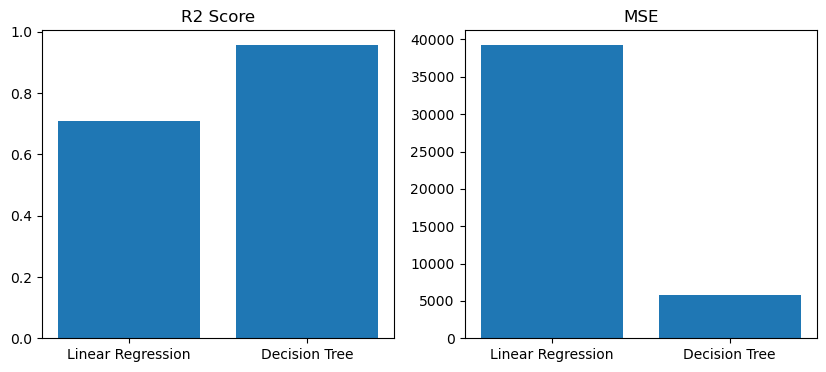

In [11]:
models = ['Linear Regression', 'Decision Tree']
r2_scores = [ 0.7091952640746721,0.9574163856381552]
rmse_scores = [39264.76084471144 ,5749.684332000001]
ig, ax = plt.subplots(1, 2, figsize=(10, 4))


ax[0].bar(models, r2_scores)
ax[0].set_title('R2 Score')

ax[1].bar(models, rmse_scores)
ax[1].set_title('MSE')

plt.show()

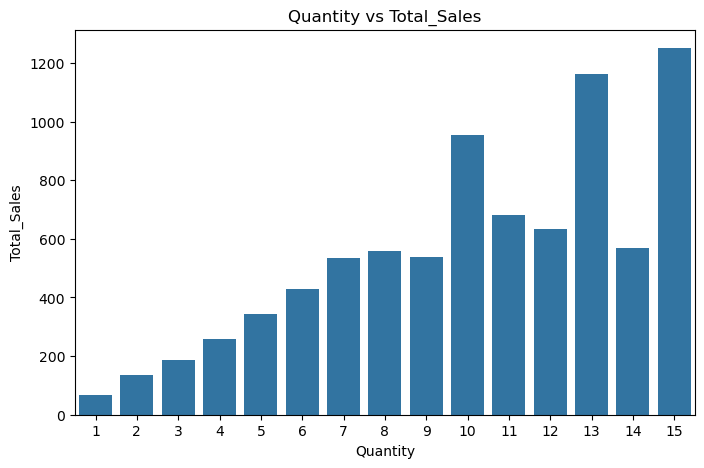

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Quantity',
    y='Total_Sales', 
    errorbar=None
)
plt.title('Quantity vs Total_Sales')
plt.xlabel('Quantity')
plt.ylabel('Total_Sales')
plt.show()

# SAVE THE MODEL

In [14]:
joblib.dump(model2, 'BUSINESS_MODEL.pkl')

['BUSINESS_MODEL.pkl']

# LOAD THE MODEL

In [15]:
model2 = joblib.load('BUSINESS_MODEL.pkl')